#  Stock Price Prediction (Short-Term)

## Introduction

This project focuses on predicting the next day’s closing price of a stock using historical market data. We aim to explore relationships between features such as Open, High, Low, and Volume, and use machine learning models for short-term forecasting.

The goal is to understand feature importance and evaluate how well regression models perform in predicting stock prices.

## Research Questions

1. Can we predict the next day’s closing price using historical stock data?
2. Which features (Open, High, Low, Volume) are most predictive?
3. How accurate are regression models for short-term prediction?
4. Do predictions follow real market trends?

## Hypothesis

It is hypothesized that historical price features (Open, High, Low) and trading Volume can help predict the next day's closing price with reasonable accuracy.

## Step 1: Import Libraries

### Purpose
To load all required libraries for data collection, processing, visualization, and modeling.

### Explanation
- `yfinance` → fetch stock data
- `pandas` → data manipulation
- `matplotlib`, `seaborn` → visualization
- `sklearn` → machine learning models

In [32]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
print("All libraries are loaded successfully!")

All libraries are loaded successfully!


## Step 2: Data Collection

### Purpose
To retrieve historical stock data using an API.

### Explanation
We use Yahoo Finance API to fetch 2 years of daily stock data.

### Expected Output
Dataset containing:
- Open, High, Low, Close prices
- Volume

### Research Insight
Reliable data collection is critical as model performance depends heavily on data quality.

In [ ]:
#Loading Data
ticker="AAPL"
data=yf.download(ticker, period="2y", interval="1d")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-04-09,168.139755,168.546061,166.831668,167.178502,42373800
2024-04-10,166.266830,167.565013,165.602875,167.277636,49709300
2024-04-11,173.461380,173.877606,166.643438,166.821808,91070300
2024-04-12,174.957764,176.751438,172.638871,172.688408,101670900
2024-04-15,171.132538,175.037006,170.944249,173.778456,73531800


## Step 3: Data Exploration

### Purpose
To understand dataset structure and statistical properties.

### Explanation
- `.info()` shows data types and missing values
- `.describe()` shows statistical summary
- `.shape()` shows shape structure or shape of the data
- `.columns` shows the total number of coloumns

### Observation
- Data is numerical and clean
- No major missing values

### Research Insight
Understanding data distribution helps in choosing the right model.

In [ ]:
#Understanding the data 
data.shape
data.columns
data.info
data.describe

<bound method NDFrame.describe of Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2024-04-09  168.139755  168.546061  166.831668  167.178502   42373800
2024-04-10  166.266830  167.565013  165.602875  167.277636   49709300
2024-04-11  173.461380  173.877606  166.643438  166.821808   91070300
2024-04-12  174.957764  176.751438  172.638871  172.688408  101670900
2024-04-15  171.132538  175.037006  170.944249  173.778456   73531800
...                ...         ...         ...         ...        ...
2026-04-02  255.919998  256.130005  250.649994  254.199997   31289400
2026-04-06  258.859985  262.160004  256.459991  256.510010   29329900
2026-04-07  253.500000  256.200012  245.699997  256.160004   62148000
2026-04-08  258.899994  259.750000  256.529999  258.450012   41008200
2026-04-09  259.024994  260.029999  256.070007  259.3699

## Step 4: Feature Selection

### Purpose
To define input features and target variable.

### Explanation
- Features: Open, High, Low, Volume
- Target: Close price

### Research Insight
Selecting relevant features is crucial for improving model accuracy and reducing noise.

In [ ]:
#Defining the Features and Labels
features = ["Open", "High", "Low", "Volume"]
target='Close'
X=data[features]
y=data[target]

print(X)
print(y)

Price             Open        High         Low     Volume
Ticker            AAPL        AAPL        AAPL       AAPL
Date                                                     
2024-04-09  167.178502  168.546061  166.831668   42373800
2024-04-10  167.277636  167.565013  165.602875   49709300
2024-04-11  166.821808  173.877606  166.643438   91070300
2024-04-12  172.688408  176.751438  172.638871  101670900
2024-04-15  173.778456  175.037006  170.944249   73531800
...                ...         ...         ...        ...
2026-04-02  254.199997  256.130005  250.649994   31289400
2026-04-06  256.510010  262.160004  256.459991   29329900
2026-04-07  256.160004  256.200012  245.699997   62148000
2026-04-08  258.450012  259.750000  256.529999   41008200
2026-04-09  259.369995  260.029999  256.070007   10905611

[502 rows x 4 columns]
Ticker            AAPL
Date                  
2024-04-09  168.139755
2024-04-10  166.266830
2024-04-11  173.461380
2024-04-12  174.957764
2024-04-15  171.132538
...

## Step 5: Train-Test Split

### Purpose
To divide data into training and testing sets.

### Explanation
- 80% training data
- 20% testing data
- No shuffling to maintain time sequence

### Research Insight
Time series data must preserve chronological order to avoid data leakage.

In [ ]:
#Splitting data into train and test 
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, shuffle=False)
print(X_test)
print(y_test)

Price             Open        High         Low    Volume
Ticker            AAPL        AAPL        AAPL      AAPL
Date                                                    
2025-11-12  274.742924  275.472253  271.446021  48398000
2025-11-13  273.853744  276.441349  271.835643  49602800
2025-11-14  270.796590  275.702003  269.347964  47431300
2025-11-17  268.568705  270.237127  265.481598  45018300
2025-11-18  269.737607  270.456935  265.071989  45677300
...                ...         ...         ...       ...
2026-04-02  254.199997  256.130005  250.649994  31289400
2026-04-06  256.510010  262.160004  256.459991  29329900
2026-04-07  256.160004  256.200012  245.699997  62148000
2026-04-08  258.450012  259.750000  256.529999  41008200
2026-04-09  259.369995  260.029999  256.070007  10905611

[101 rows x 4 columns]
Ticker            AAPL
Date                  
2025-11-12  273.214355
2025-11-13  272.694855
2025-11-14  272.155334
2025-11-17  267.209961
2025-11-18  267.190002
...              

## Step 6: Linear Regression Model
### Purpose
To build a baseline model for prediction.
### Explanation
Linear Regression assumes a linear relationship between features and target.
### Evaluation Metrics
- MSE (Mean Squared Error)
- R² Score
### Research Insight
Acts as a benchmark for comparing advanced models.

In [37]:
#Initializing the model
lr_model=LinearRegression()

#Traing the Model
lr_model.fit(X_train, y_train)

#Testing
y_predict=lr_model.predict(X_test)

#Evaluation
mse_error=mean_squared_error(y_test, y_predict)
r2_sr=r2_score(y_test,y_predict)
print(mse_error)
print(r2_sr)

2.4521394192978323
0.9755507884245935


## Step 7: Random Forest Model

### Purpose
To capture non-linear relationships in data.

### Explanation
Random Forest uses multiple decision trees to improve prediction accuracy.

### Research Insight
Stock data is often non-linear, making ensemble models more effective.

In [ ]:
#Initializing RandomForestModel Regressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

#Training the RandomForest Regressor Model
rf_model.fit(X_train, y_train)

#Prediction
y_pred=rf_model.predict(X_test)

#Evaluation
mse_rf=mean_squared_error(y_test, y_pred)
r2_rf=r2_score(y_test, y_pred)

print(mse_rf)
print(r2_rf)

c:\Users\User\Desktop\MLprojects\vevn\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


9.816044021069917
0.902128510632008


### Random Forest Model Perfomance

### Explanation
Random Forest uses multiple decision trees to model complex patterns and interactions between features.

### Observation
- In this case, Random Forest performed worse than Linear Regression.
- Higher MSE and lower R² indicate less accurate predictions.

### Research Insight
Although Random Forest is powerful for non-linear problems, it may not always outperform simpler models. This suggests that the relationship between selected features and the target variable is largely linear, or that the model requires further tuning.

## Step 8: Visualization Setup

### Purpose
To visually evaluate how well the trained models predict stock prices compared to actual values.

### Explanation
While numerical metrics like MSE and R² provide quantitative evaluation, visualizing predictions allows us to:
- Observe trend alignment
- Identify deviations and errors
- Detect underfitting or overfitting behavior

### Research Insight
Visualization is a critical step in time series analysis because it reveals patterns and model behavior that may not be evident through metrics alone.

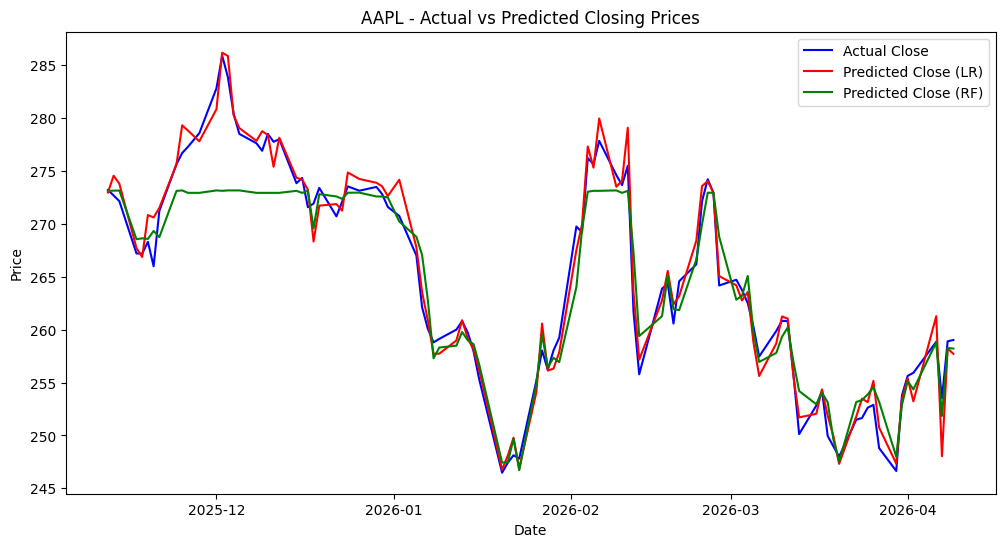

In [ ]:
# Graph Size
plt.figure(figsize=(12,6))

# Actual Graph Line
plt.plot(y_test.index, y_test, label="Actual Close", color='blue')

# Graph line by LinearRegression
plt.plot(y_test.index, y_predict, label="Predicted Close (LR)", color='red')

# Graph line by RandomForest Regressor Model
plt.plot(y_test.index, y_pred, label="Predicted Close (RF)", color='green')

# Title of the Graph
plt.title(f"{ticker} - Actual vs Predicted Closing Prices")

# labels of the Axis
plt.xlabel("Date")
plt.ylabel("Price")

# Shows labels for each plotted line
plt.legend()

# Show the graph
plt.show()

## Visualization Analysis

### Purpose
To compare actual and predicted stock prices.

### Explanation
Graphical comparison helps evaluate how closely predictions follow real trends.

### Observation
- Linear Regression predictions closely follow the actual price trend.
- Random Forest shows larger deviations and fails to capture trends accurately.

### Research Insight
This visualization confirms that Linear Regression performs better for this dataset. It suggests that the underlying relationship between features and the closing price is relatively linear for short-term prediction.

Additionally, it highlights that more complex models do not always guarantee better performance, especially when the data exhibits strong linear characteristics.

## Step 9: Feature Importance

### Purpose
To identify which features contribute most to predictions.

### Explanation
Random Forest provides importance scores for each feature.

### Research Insight
Helps in feature selection and improving future models.

In [ ]:
# To identify the important Features
importances = rf_model.feature_importances_
for feat, imp in zip(features, importances):
    print(f"{feat}: {imp:.3f}")

Open: 0.032
High: 0.342
Low: 0.625
Volume: 0.001


## Model Comparison Analysis

### Performance Summary

| Model               | MSE ↓ | R² ↑ | Performance |
|--------------------|------|------|------------|
| Linear Regression  | 2.45 | 0.975 | Excellent |
| Random Forest      | 9.81 | 0.902 | Moderate |

### Key Observations

- Linear Regression achieved significantly lower error (MSE) and higher R² score.
- Random Forest underperformed despite being a more complex model.
- Visual analysis supports these findings, with Linear Regression predictions closely aligning with actual values.

### Interpretation

- The strong performance of Linear Regression suggests that the relationship between input features (Open, High, Low) and the target (Close) is largely linear.
- Random Forest may have:
  - Overfitted the training data
  - Failed to generalize well on test data
  - Required further hyperparameter tuning

### Research Insight

This result challenges the common assumption that more complex models always perform better. Instead, it demonstrates that:

> Model performance depends more on data characteristics than model complexity.

Choosing the right model requires understanding the structure and behavior of the dataset.

## Final Conclusion

This study explored the use of machine learning models for short-term stock price prediction using historical market data.

The analysis revealed that:

- Linear Regression outperformed Random Forest in both quantitative metrics and visual evaluation.
- The strong predictive performance of Linear Regression indicates that the relationship between selected features and the closing price is predominantly linear.
- Random Forest, while capable of modeling complex relationships, did not provide additional benefits in this case and may require further tuning.

### Key Takeaways

- Simpler models can outperform complex models when data relationships are linear.
- Feature selection plays a critical role in model performance.
- Visualization is essential for understanding model behavior beyond numerical metrics.

### Final Insight

> Effective machine learning is not about using the most advanced model, but about selecting the most appropriate model based on the nature of the data.

This project demonstrates the importance of combining statistical evaluation, visualization, and critical thinking to build reliable and interpretable predictive models.